In [1]:
import time
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# Set seed for reproducibility
torch.manual_seed(123)

# Physics-Informed Neural Network (PINN) for SIR Model

This model solves the forward problem for the system of ODEs provided:
* **S**: Susceptible
* **I**: Infected
* **R**: Recovered

The model is defined by the following system of first-order ordinary differential equations:

$$
\begin{aligned}
\frac{dS}{dt} &= -\beta S(t) I(t) \\
\frac{dI}{dt} &= \beta S(t) I(t) - \gamma I(t) \\
\frac{dR}{dt} &= \gamma I(t)
\end{aligned}
$$



### Parameters and Initial Conditions

Given the constants and the state of the population at $t = 0$:

**Parameters:**
* $\beta = 0.3$
* $\gamma = 0.1$

**Initial Conditions:**
* $S(0) = 0.99$
* $I(0) = 0.01$
* $R(0) = 0$


In [2]:
class FCN(nn.Module):
    def __init__(self, N_INPUT, N_OUTPUT, N_HIDDEN, N_LAYERS):
        super().__init__()
        activation = nn.Tanh
        self.fcs = nn.Sequential(*[
                        nn.Linear(N_INPUT, N_HIDDEN),
                        activation()])
        self.fch = nn.Sequential(*[
                        nn.Sequential(*[
                            nn.Linear(N_HIDDEN, N_HIDDEN),
                            activation()]) for _ in range(N_LAYERS-1)])
        self.fce = nn.Linear(N_HIDDEN, N_OUTPUT)

    def forward(self, t):
        t = self.fcs(t)
        t = self.fch(t)
        t = self.fce(t)
        return t

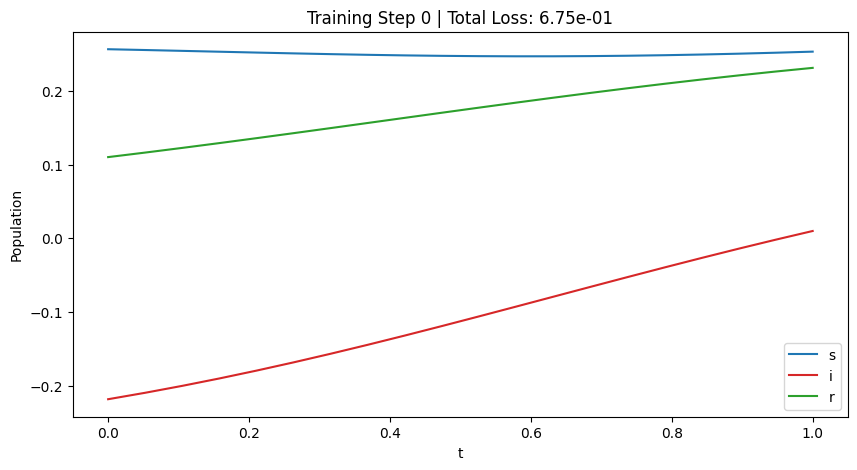

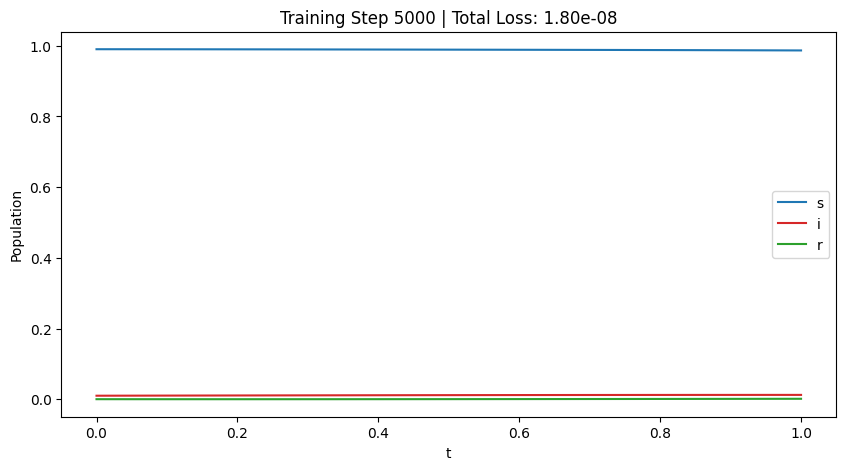

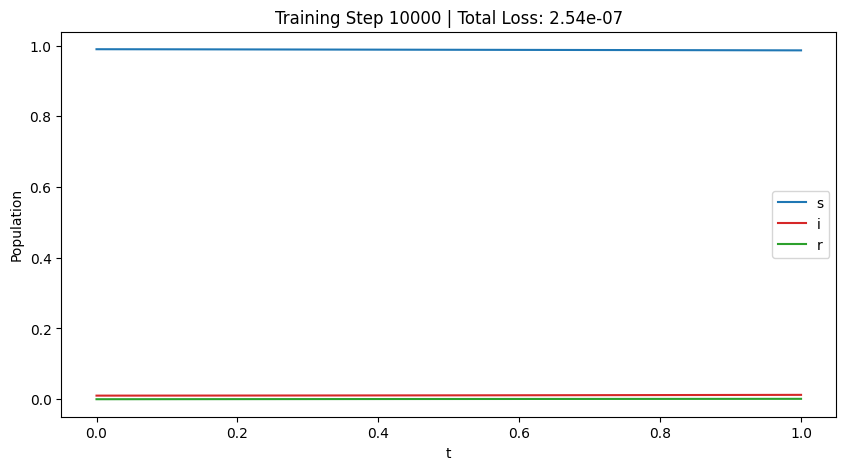

Total training time: 37.87 seconds


In [7]:
# 1. Setup Network and Data
# Input: t, Output: [u, v]
pinn = FCN(1, 3, 32, 3)

# Initial condition point (t=0)
t_boundary = torch.tensor([[0.0]], requires_grad=True)

# Collocation points for physics loss (t in [0, 1])
t_physics = torch.linspace(0, 1, 30).view(-1, 1).requires_grad_(True)

optimiser = torch.optim.Adam(pinn.parameters(), lr=1e-3)

# 2. Training Loop
start_time = time.time()
for j in range(10001):
    optimiser.zero_grad()

    # --- Initial Condition (Boundary) Loss ---
    pred_boundary = pinn(t_boundary) # Returns [s_pred, i_pred, r_pred]
    s_b = pred_boundary[:, 0]
    i_b = pred_boundary[:, 1]
    r_b = pred_boundary[:, 2]

    loss_s0 = torch.mean((s_b - 0.99) ** 2)
    loss_i0 = torch.mean((i_b - 0.01) ** 2)
    loss_r0 = torch.mean((r_b) ** 2)

    # --- Physics Loss (System of ODEs) ---
    pred = pinn(t_physics)
    s = pred[:, 0:1]
    i = pred[:, 1:2]
    r = pred[:, 2:3]

    # Gradients
    dsdt = torch.autograd.grad(s, t_physics, torch.ones_like(s), create_graph=True)[0]
    didt = torch.autograd.grad(i, t_physics, torch.ones_like(i), create_graph=True)[0]
    drdt = torch.autograd.grad(r, t_physics, torch.ones_like(r), create_graph=True)[0]

    # Residuals
    r1 = dsdt + (0.3 * s * i)
    r2 = didt - (0.3 * s * i) + (0.1 * i)
    r3 = drdt - (0.1 * i)

    loss_physics = torch.mean(r1**2) + torch.mean(r2**2) + torch.mean(r3**2)

    # --- Total Loss ---
    loss = loss_s0 + loss_i0 + loss_r0 + 1e-3 * loss_physics

    loss.backward()
    optimiser.step()

    # 3. Visualization
    if j % 5000 == 0:
        with torch.no_grad():
            t_test = torch.linspace(0, 1, 20).view(-1, 1)
            sir_test = pinn(t_test)
            s_pred = sir_test[:, 0]
            i_pred = sir_test[:, 1]
            r_pred = sir_test[:, 2]

        plt.figure(figsize=(10, 5))
        plt.plot(t_test.numpy(), s_pred.numpy(), label="s", color="tab:blue")
        plt.plot(t_test.numpy(), i_pred.numpy(), label="i", color="tab:red")
        plt.plot(t_test.numpy(), r_pred.numpy(), label="r", color="tab:green")
        plt.title(f"Training Step {j} | Total Loss: {loss.item():.2e}")
        plt.xlabel("t")
        plt.ylabel("Population")
        plt.legend()
        plt.show()

print(f"Total training time: {time.time() - start_time:.2f} seconds")

In [4]:
# 1. Define collocation points
t_obs = torch.linspace(0, 1, 30).view(-1, 1)

# 2. Generate true data from forward PINN
with torch.no_grad():
    forward_pred = pinn(t_obs)
    s_true = forward_pred[:, 0:1]
    i_true = forward_pred[:, 1:2]
    r_true = forward_pred[:, 2:3]

# 3. Add 2% Gaussian noise to simulate experimental error for obs data
noise_level = 0.02
s_obs = s_true + noise_level * torch.randn_like(s_true)
i_obs = i_true + noise_level * torch.randn_like(i_true)
r_obs =r_true + noise_level * torch.randn_like(r_true)

# Detach to ensure these are constants for the inverse problem
s_obs, i_obs, r_obs = s_obs.detach(), i_obs.detach(), r_obs.detach()

In [5]:
# 1. Setup Network (Input: t, Output: [u, v])
pinn_inv = FCN(1, 3, 32, 3)

# 2. Define unknown parameters as trainable variables
# Initial guesses: starting at 1.0 for both
beta = nn.Parameter(torch.tensor([1.0], requires_grad=True))
gamma = nn.Parameter(torch.tensor([1.0], requires_grad=True))

# 3. Define collocation points
t_physics = torch.linspace(0, 1, 20).view(-1, 1).requires_grad_(True)

# 4. Optimizer includes the parameters alpha and beta
optimizer = torch.optim.Adam(list(pinn_inv.parameters()) + [beta, gamma], lr=1e-3)

Iteration 0 | Loss: 8.39e-01 | beta: 1.0000 | gamma: 1.0000
Iteration 2000 | Loss: 1.24e-03 | beta: 1.0000 | gamma: 1.0000
Iteration 4000 | Loss: 1.24e-03 | beta: 1.0000 | gamma: 1.0000
Iteration 6000 | Loss: 1.24e-03 | beta: 1.0000 | gamma: 1.0000

Final discovered alpha: 1.0000 (True: 2.0)
Final discovered beta: 1.0000 (True: 1.0)
Total training time: 22.52 seconds


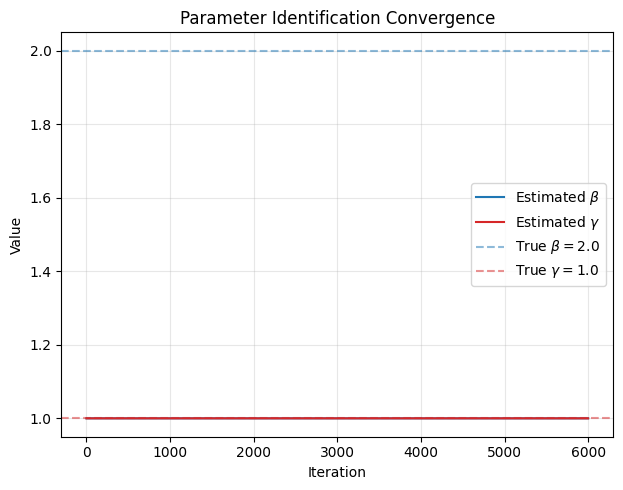

In [6]:
# Lists to store the history of alpha and beta for plotting
beta_history = []
gamma_history = []
loss_history = []

start_time = time.time()
iterations = 6001

for j in range(iterations):
    optimizer.zero_grad()

    # --- Data Loss ---
    # Compare predictions at the noisy observation points
    pred_obs = pinn_inv(t_obs)
    s_pred_obs = pred_obs[:, 0:1]
    i_pred_obs = pred_obs[:, 1:2]
    r_pred_obs = pred_obs[:, 2:3]
    loss_data = torch.mean((s_pred_obs - s_obs)**2) + torch.mean((i_pred_obs - i_obs)**2) + torch.mean((r_pred_obs - r_obs)**2)

    # --- Physics Loss ---
    # Calculate residuals using automatic differentiation and trainable alpha/beta
    pred = pinn_inv(t_physics)
    s = pred[:, 0:1]
    i = pred[:, 1:2]
    r = pred[:, 2:3]

    dsdt = torch.autograd.grad(s, t_physics, torch.ones_like(s), create_graph=True)[0]
    didt = torch.autograd.grad(i, t_physics, torch.ones_like(i), create_graph=True)[0]
    drdt = torch.autograd.grad(r, t_physics, torch.ones_like(r), create_graph=True)[0]

    r1 = dsdt + (0.3 * s * i)
    r2 = didt - (0.3 * s * i) + (0.1 * i)
    r3 = drdt - (0.1 * i)

    loss_physics = torch.mean(r1**2) + torch.mean(r2**2) + torch.mean(r3**2)

    # --- Total Loss ---
    loss = loss_data + loss_physics
    loss.backward()
    optimizer.step()

    # Record history for plotting
    beta_history.append(beta.item())
    gamma_history.append(gamma.item())
    loss_history.append(loss.item())

    if j % 2000 == 0:
        print(f"Iteration {j} | Loss: {loss.item():.2e} | beta: {beta.item():.4f} | gamma: {gamma.item():.4f}")

print(f"\nFinal discovered alpha: {beta.item():.4f} (True: 2.0)")
print(f"Final discovered beta: {gamma.item():.4f} (True: 1.0)")
print(f"Total training time: {time.time() - start_time:.2f} seconds")

# --- Plotting the Parameter Convergence ---
plt.figure(figsize=(12, 5))

# Plot Alpha and Beta convergence
plt.subplot(1, 2, 1)
plt.plot(beta_history, label=r'Estimated $\beta$', color='tab:blue')
plt.plot(gamma_history, label=r'Estimated $\gamma$', color='tab:red')
plt.axhline(y=2.0, color='tab:blue', linestyle='--', alpha=0.5, label=r'True $\beta=2.0$')
plt.axhline(y=1.0, color='tab:red', linestyle='--', alpha=0.5, label=r'True $\gamma=1.0$')
plt.title("Parameter Identification Convergence")
plt.xlabel("Iteration")
plt.ylabel("Value")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()